In [31]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.metrics import utility_gap

In [32]:
graph_type = 'barbasi_albert'
folder = 'size_500'
size = '500'

## Comparison of Kempe Greedy vs. Welfare Greedy

In [33]:
df_k_var = pd.read_csv(f'{graph_type}/{folder}/kempe_welfare_k_variation_{graph_type}_{size}.csv')

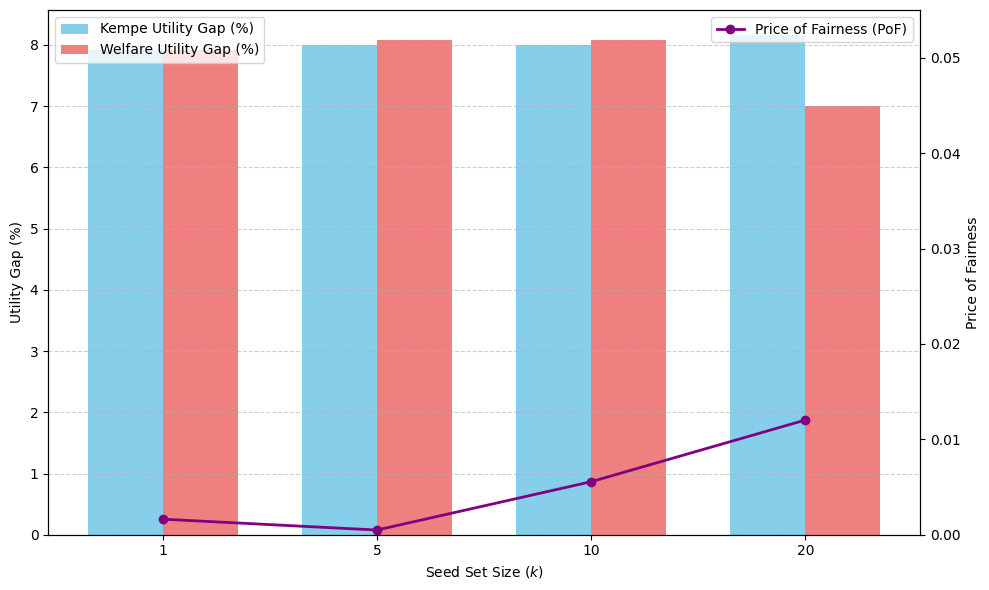

In [34]:
for method in ['kempe', 'welfare']:
    df_k_var[f'{method}_gap'] = df_k_var[f'{method}_influence_by_community'].apply(
        lambda s: utility_gap(ast.literal_eval(s)) if isinstance(s, str) else utility_gap(s)
    )

x = np.arange(len(df_k_var))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(x - bar_width / 2, df_k_var['kempe_gap'], width=bar_width, label='Kempe Utility Gap (%)', color='skyblue')
ax1.bar(x + bar_width / 2, df_k_var['welfare_gap'], width=bar_width, label='Welfare Utility Gap (%)',
        color='lightcoral')
ax1.set_xlabel('Seed Set Size ($k$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(df_k_var['k'])
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(x, df_k_var['price_of_fairness'], color='purple', marker='o', linewidth=2, label='Price of Fairness (PoF)')
ax2.set_ylabel('Price of Fairness')
ax2.set_ylim(0, max(df_k_var['price_of_fairness'].max(), 0.05) * 1.1)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [35]:
df_alpha_var = pd.read_csv(f'{graph_type}/{folder}/kempe_welfare_alpha_variation_{graph_type}_{size}.csv')

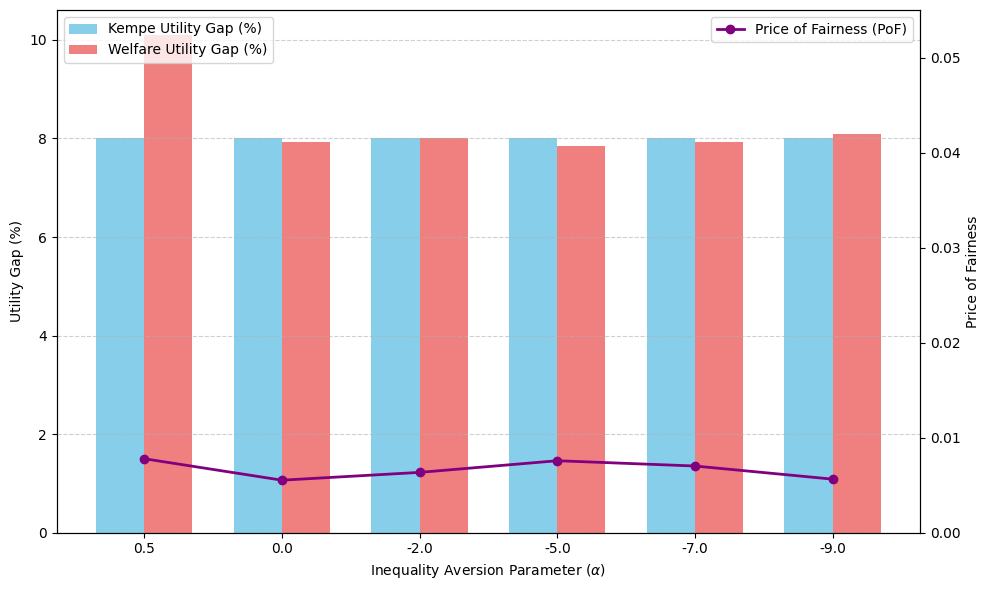

In [36]:
for method in ['kempe', 'welfare']:
    df_alpha_var[f'{method}_gap'] = df_alpha_var[f'{method}_influence_by_community'].apply(
        lambda s: utility_gap(ast.literal_eval(s)) if isinstance(s, str) else utility_gap(s)
    )

x = np.arange(len(df_alpha_var))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(x - bar_width / 2, df_alpha_var['kempe_gap'], width=bar_width, label='Kempe Utility Gap (%)', color='skyblue')
ax1.bar(x + bar_width / 2, df_alpha_var['welfare_gap'], width=bar_width, label='Welfare Utility Gap (%)',
        color='lightcoral')
ax1.set_xlabel(r'Inequality Aversion Parameter ($\alpha$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(df_alpha_var['alpha'])
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

# Plot PoF on twin axis
ax2 = ax1.twinx()
ax2.plot(x, df_alpha_var['price_of_fairness'], color='purple', marker='o', linewidth=2, label='Price of Fairness (PoF)')
ax2.set_ylabel('Price of Fairness')
ax2.set_ylim(0, max(df_alpha_var['price_of_fairness'].max(), 0.05) * 1.1)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## Comparison of Welfare Greedy vs. Budgeted Welfare Greedy (CFIM)

In [37]:
df_welfare_cfim = pd.read_csv(f'{graph_type}/{folder}/welfare_cfim_alpha_comparison_{graph_type}_{size}.csv')

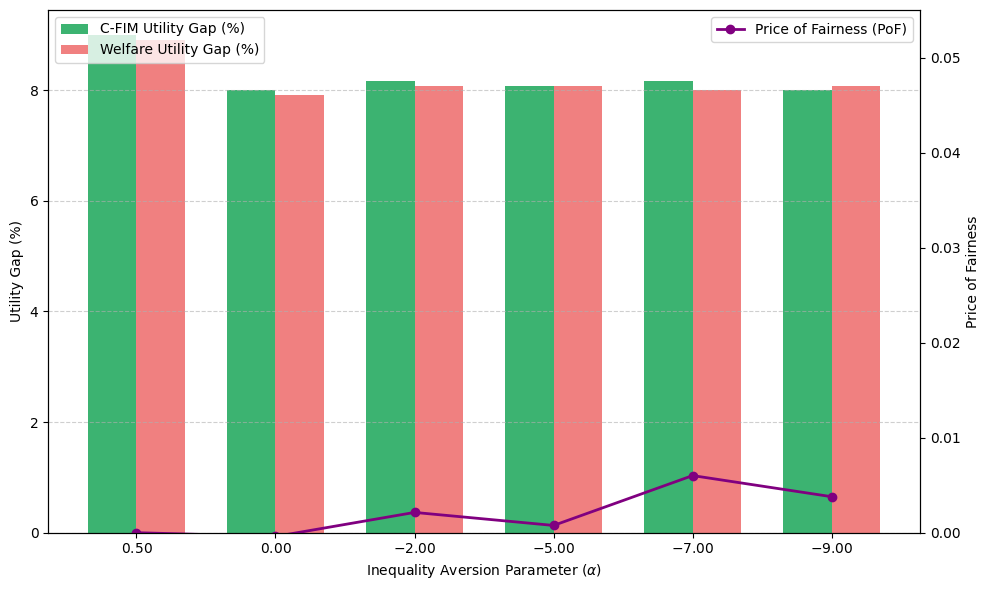

In [38]:
for method in ['cfim', 'welfare']:
    df_welfare_cfim[f'{method}_gap'] = df_welfare_cfim[f'{method}_influence_by_community'].apply(
        lambda s: utility_gap(ast.literal_eval(s)) if isinstance(s, str) else utility_gap(s)
    )

df_welfare_cfim['PoF'] = 1 - (
        df_welfare_cfim['welfare_total_influence'] / df_welfare_cfim['cfim_total_influence'].replace(0, np.nan)
)
df_welfare_cfim['PoF'] = df_welfare_cfim['PoF'].fillna(0)

# Plot setup
x = np.arange(len(df_welfare_cfim))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for utility gaps
ax1.bar(x - bar_width / 2, df_welfare_cfim['cfim_gap'], width=bar_width, label='C-FIM Utility Gap (%)',
        color='mediumseagreen')
ax1.bar(x + bar_width / 2, df_welfare_cfim['welfare_gap'], width=bar_width, label='Welfare Utility Gap (%)',
        color='lightcoral')
ax1.set_xlabel(r'Inequality Aversion Parameter ($\alpha$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels([f"${a:.2f}$" for a in df_welfare_cfim['alpha']])
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

# Line plot for PoF
ax2 = ax1.twinx()
ax2.plot(x, df_welfare_cfim['PoF'], color='purple', marker='o', linewidth=2, label='Price of Fairness (PoF)')
ax2.set_ylabel('Price of Fairness')
ax2.set_ylim(0, max(df_welfare_cfim['PoF'].max(), 0.05) * 1.1)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Comparison of Welfare Greedy vs. Water Filling Greedy

In [39]:
df_welfare_wfg = pd.read_csv(f'{graph_type}/{folder}/welfare_wfg_alpha_comparison_{graph_type}_{size}.csv')

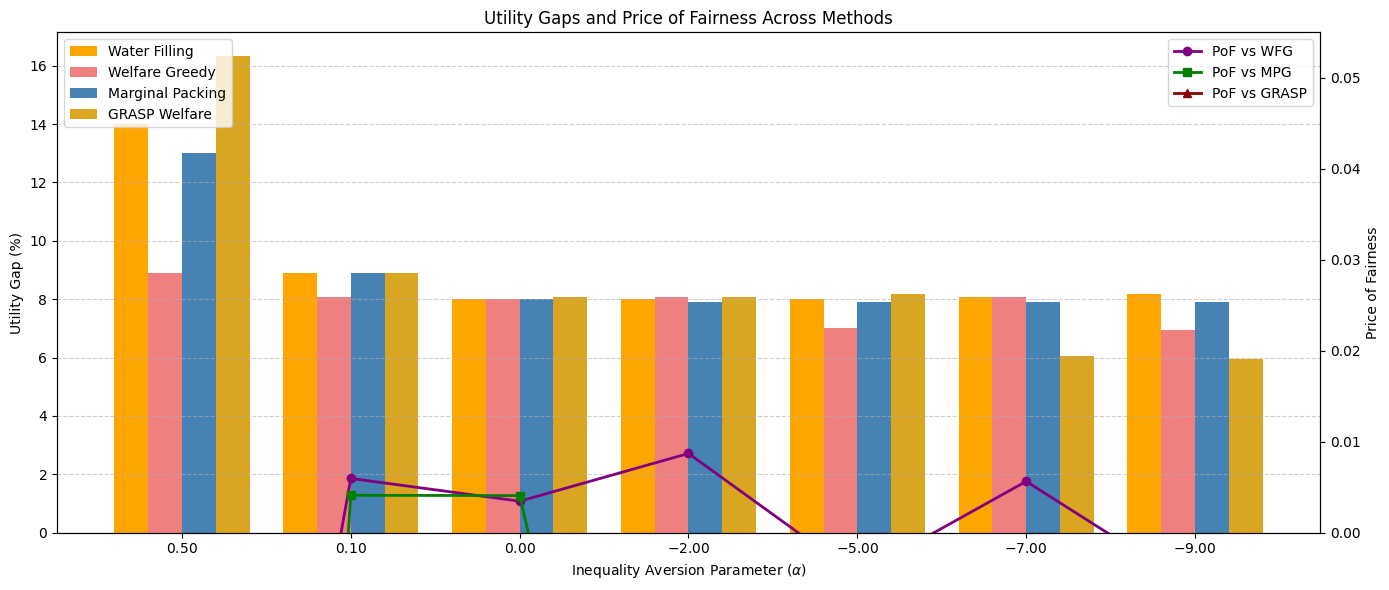

In [40]:
for method in ['wfg', 'welfare', 'mpg', 'grasp']:
    df_welfare_wfg[f'{method}_gap'] = df_welfare_wfg[f'{method}_influence_by_community'].apply(
        lambda s: utility_gap(ast.literal_eval(s)) if isinstance(s, str) else utility_gap(s)
    )

df_welfare_wfg['PoF_WFG'] = 1 - (
        df_welfare_wfg['welfare_total_influence'] / df_welfare_wfg['wfg_total_influence'].replace(0, np.nan)
)
df_welfare_wfg['PoF_MPG'] = 1 - (
        df_welfare_wfg['welfare_total_influence'] / df_welfare_wfg['mpg_total_influence'].replace(0, np.nan)
)
df_welfare_wfg['PoF_GRASP'] = 1 - (
        df_welfare_wfg['welfare_total_influence'] / df_welfare_wfg['grasp_total_influence'].replace(0, np.nan)
)
df_welfare_wfg[['PoF_WFG', 'PoF_MPG', 'PoF_GRASP']] = df_welfare_wfg[['PoF_WFG', 'PoF_MPG', 'PoF_GRASP']].fillna(0)

bar_width = 0.2
x = np.arange(len(df_welfare_wfg))

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(x - 1.5 * bar_width, df_welfare_wfg['wfg_gap'], width=bar_width, label='Water Filling', color='orange')
ax1.bar(x - 0.5 * bar_width, df_welfare_wfg['welfare_gap'], width=bar_width, label='Welfare Greedy', color='lightcoral')
ax1.bar(x + 0.5 * bar_width, df_welfare_wfg['mpg_gap'], width=bar_width, label='Marginal Packing', color='steelblue')
ax1.bar(x + 1.5 * bar_width, df_welfare_wfg['grasp_gap'], width=bar_width, label='GRASP Welfare', color='goldenrod')

ax1.set_xlabel(r'Inequality Aversion Parameter ($\alpha$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels([f"${a:.2f}$" for a in df_welfare_wfg['alpha']])
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(x, df_welfare_wfg['PoF_WFG'], color='purple', marker='o', linewidth=2, label='PoF vs WFG')
ax2.plot(x, df_welfare_wfg['PoF_MPG'], color='green', marker='s', linewidth=2, label='PoF vs MPG')
ax2.plot(x, df_welfare_wfg['PoF_GRASP'], color='darkred', marker='^', linewidth=2, label='PoF vs GRASP')

ax1.set_xlabel(r'Inequality Aversion Parameter ($\alpha$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels([f"${a:.2f}$" for a in df_welfare_wfg['alpha']])
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

ax2.set_ylabel('Price of Fairness')
ax2.set_ylim(0, max(df_welfare_wfg[['PoF_WFG', 'PoF_MPG', 'PoF_GRASP']].max().max(), 0.05) * 1.1)
ax2.legend(loc='upper right')

plt.title('Utility Gaps and Price of Fairness Across Methods')
plt.tight_layout()
plt.show()